In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install catboost
!pip install lightgbm
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

In [4]:
df_normal = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')

In [10]:
# OPTUNA OPTIMIZATION WITH ENGINEERED FEATURES
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import numpy as np
import pandas as pd
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Start with your base dataframe
native_df = df_normal.copy()

# ==================== FEATURE ENGINEERING ====================
print("Creating engineered features...")

# Age-related features
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})

# Severity indicators (binary flags)
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)

# Convert severity to numeric for interactions
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)

# Interaction features
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric

# Geographic features
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)

# Healthcare utilization
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

print(f"✓ Created 8 new engineered features")

# Identify categorical columns
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment Typology 1'
]

# Prepare data
X = native_df.drop('length_of_stay', axis=1)
y = native_df['length_of_stay']

# Clean column names
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Update cat_features with cleaned names
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==================== PREPARE DATA FOR LIGHTGBM ====================
# LightGBM needs categorical features encoded as integers
print("\nEncoding categorical features for LightGBM...")

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

# Store label encoders for each categorical column
label_encoders = {}

for col in cat_features_cleaned:
    if col in X_train_lgb.columns:
        le = LabelEncoder()

        # Fit on combined train+test to handle unseen categories
        combined = pd.concat([X_train_lgb[col], X_test_lgb[col]]).astype(str)
        le.fit(combined)

        # Transform train and test
        X_train_lgb[col] = le.transform(X_train_lgb[col].astype(str))
        X_test_lgb[col] = le.transform(X_test_lgb[col].astype(str))

        label_encoders[col] = le

# Convert boolean columns to int
bool_cols = X_train_lgb.select_dtypes(include='bool').columns
X_train_lgb[bool_cols] = X_train_lgb[bool_cols].astype(int)
X_test_lgb[bool_cols] = X_test_lgb[bool_cols].astype(int)

print(f"✓ Encoded {len(label_encoders)} categorical features")
print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Total features: {X_train.shape[1]}")

# ==================== LightGBM Hyperparameter Tuning ====================
print("\n" + "="*70)
print("TUNING LIGHTGBM HYPERPARAMETERS")
print("="*70)

def objective_lgb(trial):
    """Objective function for LightGBM hyperparameter tuning"""

    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,
        'device': 'gpu',  # Enable GPU
        'gpu_platform_id': 0,
        'gpu_device_id': 0,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'n_estimators': 1000
    }

    model = lgb.LGBMRegressor(**param)

    model.fit(
        X_train_lgb, y_train,
        eval_set=[(X_test_lgb, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    y_pred = model.predict(X_test_lgb)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return rmse

# Run optimization for LightGBM
study_lgb = optuna.create_study(direction='minimize', study_name='lightgbm_tuning')
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print("\n" + "="*70)
print("LIGHTGBM TUNING RESULTS")
print("="*70)
print(f"Best RMSE: {study_lgb.best_value:.4f}")
print(f"\nBest Parameters:")
for key, value in study_lgb.best_params.items():
    print(f"  {key}: {value}")

# Train final LightGBM model with best parameters
print("\nTraining final LightGBM model with best parameters...")
best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({
    'objective': 'regression',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'n_estimators': 1000,
    'device': 'gpu',  # Enable GPU
    'gpu_platform_id': 0,
    'gpu_device_id': 0
})

evals_result_lgb = {}
lgb_model_tuned = lgb.LGBMRegressor(**best_lgb_params)
lgb_model_tuned.fit(
    X_train_lgb, y_train,
    eval_set=[(X_train_lgb, y_train), (X_test_lgb, y_test)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.record_evaluation(evals_result_lgb)
    ]
)

# Evaluate tuned LightGBM
y_pred_lgb_train = lgb_model_tuned.predict(X_train_lgb)
y_pred_lgb_test = lgb_model_tuned.predict(X_test_lgb)

lgb_tuned_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_lgb_train))
lgb_tuned_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))
lgb_tuned_train_mae = mean_absolute_error(y_train, y_pred_lgb_train)
lgb_tuned_test_mae = mean_absolute_error(y_test, y_pred_lgb_test)
lgb_tuned_train_r2 = r2_score(y_train, y_pred_lgb_train)
lgb_tuned_test_r2 = r2_score(y_test, y_pred_lgb_test)

print("\nTuned LightGBM Results:")
print(f"Train RMSE: {lgb_tuned_train_rmse:.4f} | Test RMSE: {lgb_tuned_test_rmse:.4f}")
print(f"Train MAE: {lgb_tuned_train_mae:.4f} | Test MAE: {lgb_tuned_test_mae:.4f}")
print(f"Train R²: {lgb_tuned_train_r2:.4f} | Test R²: {lgb_tuned_test_r2:.4f}")

# Save tuned LightGBM model and encoders
joblib.dump({
    'model': lgb_model_tuned,
    'label_encoders': label_encoders
}, 'models/lightgbm_model_tuned.pkl')
print("✓ Tuned LightGBM model saved to 'models/lightgbm_model_tuned.pkl'")




Creating engineered features...
✓ Created 8 new engineered features

Encoding categorical features for LightGBM...


[I 2025-12-04 18:15:19,878] A new study created in memory with name: lightgbm_tuning


✓ Encoded 17 categorical features

Training set size: (2078162, 25)
Test set size: (519541, 25)
Total features: 25

TUNING LIGHTGBM HYPERPARAMETERS


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-04 18:16:25,326] Trial 0 finished with value: 6.799844015029813 and parameters: {'learning_rate': 0.026186192897815617, 'num_leaves': 95, 'max_depth': 12, 'min_child_samples': 54, 'subsample': 0.6252401236325243, 'colsample_bytree': 0.771271679083341, 'reg_alpha': 0.49587920427741083, 'reg_lambda': 2.5409534776596742e-08, 'min_split_gain': 0.9824939727845341}. Best is trial 0 with value: 6.799844015029813.
[I 2025-12-04 18:17:12,547] Trial 1 finished with value: 6.82813489379981 and parameters: {'learning_rate': 0.04810088856716787, 'num_leaves': 54, 'max_depth': 6, 'min_child_samples': 40, 'subsample': 0.8247243612203248, 'colsample_bytree': 0.8737741734837152, 'reg_alpha': 0.3624152001596013, 'reg_lambda': 0.010091521142263322, 'min_split_gain': 0.6477364833924167}. Best is trial 0 with value: 6.799844015029813.
[I 2025-12-04 18:18:09,417] Trial 2 finished with value: 6.829873296954701 and parameters: {'learning_rate': 0.024171240690213047, 'num_leaves': 79, 'max_depth': 9

FileNotFoundError: [Errno 2] No such file or directory: 'models/lightgbm_model_tuned.pkl'

In [11]:
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# Save tuned LightGBM model and encoders
joblib.dump({
    'model': lgb_model_tuned,
    'label_encoders': label_encoders
}, 'models/lightgbm_model_tuned.pkl')
print("✓ Tuned LightGBM model saved to 'models/lightgbm_model_tuned.pkl'")

✓ Tuned LightGBM model saved to 'models/lightgbm_model_tuned.pkl'


In [ ]:
# Load Light gbm model


In [ ]:
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# ==================== RECREATE THE SAME DATA PREPROCESSING ====================
print("Recreating data preprocessing...")

native_df = df_normal.copy()

# Feature engineering (MUST BE IDENTICAL TO BEFORE)
print("Creating engineered features...")

native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})

native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)

severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)

native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric

native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

print(f"✓ Created 8 new engineered features")

# Identify categorical columns
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment Typology 1'
]

# Prepare data
X = native_df.drop('length_of_stay', axis=1)
y = native_df['length_of_stay']

# Clean column names (MUST BE IDENTICAL)
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Update cat_features with cleaned names
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

# Train-test split (SAME RANDOM STATE!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# ==================== LOAD SAVED LIGHTGBM MODEL ====================
print("\n" + "="*70)
print("LOADING SAVED LIGHTGBM MODEL")
print("="*70)

lgb_saved = joblib.load('/content/lightgbm_model_tuned.pkl')
lgb_model_tuned = lgb_saved['model']
label_encoders = lgb_saved['label_encoders']

print("✓ LightGBM model loaded successfully")

# Quick verification
X_test_lgb = X_test.copy()
for col in cat_features_cleaned:
    if col in X_test_lgb.columns and col in label_encoders:
        X_test_lgb[col] = label_encoders[col].transform(X_test_lgb[col].astype(str))

bool_cols = X_test_lgb.select_dtypes(include='bool').columns
X_test_lgb[bool_cols] = X_test_lgb[bool_cols].astype(int)

y_pred_lgb_test = lgb_model_tuned.predict(X_test_lgb)
lgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))
lgb_test_mae = mean_absolute_error(y_test, y_pred_lgb_test)
lgb_test_r2 = r2_score(y_test, y_pred_lgb_test)

print(f"Verified LightGBM Test RMSE: {lgb_test_rmse:.4f}")
print(f"Verified LightGBM Test MAE: {lgb_test_mae:.4f}")
print(f"Verified LightGBM Test R²: {lgb_test_r2:.4f}")

# ==================== TRAIN CATBOOST WITH BEST PARAMS ====================
print("\n" + "="*70)
print("TRAINING CATBOOST WITH BEST PARAMETERS FROM OPTUNA")
print("="*70)

# CatBoost can handle categorical features natively
cat_features_indices = [X_train.columns.get_loc(col) for col in cat_features_cleaned
                        if col in X_train.columns]

print(f"Using {len(cat_features_indices)} categorical features")

# YOUR BEST PARAMETERS FROM OPTUNA (you need to provide these)
# Based on your log, update with the actual best trial parameters
# For now, I'll use placeholders - REPLACE THESE WITH YOUR ACTUAL BEST PARAMS!
best_cat_params = {
    'iterations': 1000,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 50,
    'task_type': 'GPU',  # Change to 'CPU' if no GPU
    'cat_features': cat_features_indices,

    # REPLACE THESE WITH YOUR ACTUAL BEST CATBOOST PARAMS FROM OPTUNA:
    'learning_rate': 0.05,  # UPDATE
    'depth': 6,  # UPDATE
    'l2_leaf_reg': 3,  # UPDATE
    'bagging_temperature': 0.5,  # UPDATE
    'random_strength': 1,  # UPDATE
    'border_count': 128,  # UPDATE
    'min_data_in_leaf': 20,  # UPDATE
}

print("\nCatBoost Parameters:")
for key, value in best_cat_params.items():
    if key != 'cat_features':
        print(f"  {key}: {value}")

print("\nTraining CatBoost model...")
catboost_model_tuned = CatBoostRegressor(**best_cat_params)
catboost_model_tuned.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=100
)

# ==================== EVALUATE CATBOOST ====================
print("\n" + "="*70)
print("CATBOOST EVALUATION")
print("="*70)

y_pred_cat_train = catboost_model_tuned.predict(X_train)
y_pred_cat_test = catboost_model_tuned.predict(X_test)

cat_tuned_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_cat_train))
cat_tuned_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat_test))
cat_tuned_train_mae = mean_absolute_error(y_train, y_pred_cat_train)
cat_tuned_test_mae = mean_absolute_error(y_test, y_pred_cat_test)
cat_tuned_train_r2 = r2_score(y_train, y_pred_cat_train)
cat_tuned_test_r2 = r2_score(y_test, y_pred_cat_test)

print("\nTuned CatBoost Results:")
print(f"Train RMSE: {cat_tuned_train_rmse:.4f} | Test RMSE: {cat_tuned_test_rmse:.4f}")
print(f"Train MAE: {cat_tuned_train_mae:.4f} | Test MAE: {cat_tuned_test_mae:.4f}")
print(f"Train R²: {cat_tuned_train_r2:.4f} | Test R²: {cat_tuned_test_r2:.4f}")

# ==================== SAVE CATBOOST MODEL ====================
joblib.dump(catboost_model_tuned, 'models/catboost_model_tuned.pkl')
print("\n✓ Tuned CatBoost model saved to 'models/catboost_model_tuned.pkl'")

# ==================== FINAL COMPARISON ====================
print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['LightGBM (Before)', 'LightGBM (After)', 'CatBoost (Before)', 'CatBoost (After)'],
    'Test RMSE': [6.8380, lgb_test_rmse, 7.0450, cat_tuned_test_rmse],
    'Test MAE': [3.2198, lgb_test_mae, 3.3406, cat_tuned_test_mae],
    'Test R²': [0.4593, lgb_test_r2, 0.4261, cat_tuned_test_r2],
    'Improvement': [
        'Baseline',
        f"{((6.8380 - lgb_test_rmse) / 6.8380 * 100):.2f}

In [5]:
# Retrain Catboost + SAVE MODEL
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# ==================== RECREATE THE SAME DATA PREPROCESSING ====================
print("Recreating data preprocessing...")

native_df = df_normal.copy()

# Feature engineering (MUST BE IDENTICAL TO BEFORE)
print("Creating engineered features...")

native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})

native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)

severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)

native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric

native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

print(f"✓ Created 8 new engineered features")

# Identify categorical columns
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment Typology 1'
]

# Prepare data
X = native_df.drop('length_of_stay', axis=1)
y = native_df['length_of_stay']

# Clean column names (MUST BE IDENTICAL)
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Update cat_features with cleaned names
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

# Train-test split (SAME RANDOM STATE!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# ==================== LOAD SAVED LIGHTGBM MODEL ====================
print("\n" + "="*70)
print("LOADING SAVED LIGHTGBM MODEL")
print("="*70)

lgb_saved = joblib.load('/content/lightgbm_model_tuned.pkl')
lgb_model_tuned = lgb_saved['model']
label_encoders = lgb_saved['label_encoders']

print("✓ LightGBM model loaded successfully")

# Quick verification
X_test_lgb = X_test.copy()
for col in cat_features_cleaned:
    if col in X_test_lgb.columns and col in label_encoders:
        X_test_lgb[col] = label_encoders[col].transform(X_test_lgb[col].astype(str))

bool_cols = X_test_lgb.select_dtypes(include='bool').columns
X_test_lgb[bool_cols] = X_test_lgb[bool_cols].astype(int)

y_pred_lgb_test = lgb_model_tuned.predict(X_test_lgb)
lgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))
lgb_test_mae = mean_absolute_error(y_test, y_pred_lgb_test)
lgb_test_r2 = r2_score(y_test, y_pred_lgb_test)

print(f"Verified LightGBM Test RMSE: {lgb_test_rmse:.4f}")
print(f"Verified LightGBM Test MAE: {lgb_test_mae:.4f}")
print(f"Verified LightGBM Test R²: {lgb_test_r2:.4f}")

# ==================== TRAIN CATBOOST WITH BEST PARAMS ====================
print("\n" + "="*70)
print("TRAINING CATBOOST WITH BEST PARAMETERS FROM OPTUNA")
print("="*70)

# CatBoost can handle categorical features natively
cat_features_indices = [X_train.columns.get_loc(col) for col in cat_features_cleaned
                        if col in X_train.columns]

print(f"Using {len(cat_features_indices)} categorical features")

# YOUR BEST PARAMETERS FROM OPTUNA (you need to provide these)
# Based on your log, update with the actual best trial parameters
# For now, I'll use placeholders - REPLACE THESE WITH YOUR ACTUAL BEST PARAMS!
best_cat_params = {
    'iterations': 1000,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 50,
    'task_type': 'GPU',  # Change to 'CPU' if no GPU
    'cat_features': cat_features_indices,

    # REPLACE THESE WITH YOUR ACTUAL BEST CATBOOST PARAMS FROM OPTUNA:
    'learning_rate': 0.05,  # UPDATE
    'depth': 6,  # UPDATE
    'l2_leaf_reg': 3,  # UPDATE
    'bagging_temperature': 0.5,  # UPDATE
    'random_strength': 1,  # UPDATE
    'border_count': 128,  # UPDATE
    'min_data_in_leaf': 20,  # UPDATE
}

print("\nCatBoost Parameters:")
for key, value in best_cat_params.items():
    if key != 'cat_features':
        print(f"  {key}: {value}")

print("\nTraining CatBoost model...")
catboost_model_tuned = CatBoostRegressor(**best_cat_params)
catboost_model_tuned.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=100
)

# ==================== EVALUATE CATBOOST ====================
print("\n" + "="*70)
print("CATBOOST EVALUATION")
print("="*70)

y_pred_cat_train = catboost_model_tuned.predict(X_train)
y_pred_cat_test = catboost_model_tuned.predict(X_test)

cat_tuned_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_cat_train))
cat_tuned_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat_test))
cat_tuned_train_mae = mean_absolute_error(y_train, y_pred_cat_train)
cat_tuned_test_mae = mean_absolute_error(y_test, y_pred_cat_test)
cat_tuned_train_r2 = r2_score(y_train, y_pred_cat_train)
cat_tuned_test_r2 = r2_score(y_test, y_pred_cat_test)

print("\nTuned CatBoost Results:")
print(f"Train RMSE: {cat_tuned_train_rmse:.4f} | Test RMSE: {cat_tuned_test_rmse:.4f}")
print(f"Train MAE: {cat_tuned_train_mae:.4f} | Test MAE: {cat_tuned_test_mae:.4f}")
print(f"Train R²: {cat_tuned_train_r2:.4f} | Test R²: {cat_tuned_test_r2:.4f}")

# ==================== SAVE CATBOOST MODEL ====================
joblib.dump(catboost_model_tuned, 'models/catboost_model_tuned.pkl')
print("\n✓ Tuned CatBoost model saved to 'models/catboost_model_tuned.pkl'")

# ==================== FINAL COMPARISON ====================
print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['LightGBM (Before)', 'LightGBM (After)', 'CatBoost (Before)', 'CatBoost (After)'],
    'Test RMSE': [6.8380, lgb_test_rmse, 7.0450, cat_tuned_test_rmse],
    'Test MAE': [3.2198, lgb_test_mae, 3.3406, cat_tuned_test_mae],
    'Test R²': [0.4593, lgb_test_r2, 0.4261, cat_tuned_test_r2],
    'Improvement': [
        'Baseline',
        f"{((6.8380 - lgb_test_rmse) / 6.8380 * 100):.2f}%",
        'Baseline',
        f"{((7.0450 - cat_tuned_test_rmse) / 7.0450 * 100):.2f}%"
    ]
})

print(comparison_df.to_string(index=False))

# ==================== GENERATE PLOTS ====================
print("\n" + "="*70)
print("GENERATING COMPARISON PLOTS")
print("="*70)

# 1. Before/After comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = ['LightGBM\n(Before)', 'LightGBM\n(After)', 'CatBoost\n(Before)', 'CatBoost\n(After)']
rmse_values = [6.8380, lgb_test_rmse, 7.0450, cat_tuned_test_rmse]
colors = ['skyblue', 'blue', 'lightsalmon', 'orangered']

bars = ax.bar(models, rmse_values, color=colors, alpha=0.7)
ax.set_ylabel('Test RMSE', fontsize=12)
ax.set_title('Model Performance: Before vs After Tuning', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, rmse_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add improvement percentage
    if i == 1:  # LightGBM after
        improvement = ((6.8380 - val) / 6.8380 * 100)
        ax.text(bar.get_x() + bar.get_width()/2., height * 0.5,
                f'↓{improvement:.2f}%', ha='center', va='center', fontsize=10,
                color='green', fontweight='bold')
    elif i == 3:  # CatBoost after
        improvement = ((7.0450 - val) / 7.0450 * 100)
        ax.text(bar.get_x() + bar.get_width()/2., height * 0.5,
                f'↓{improvement:.2f}%', ha='center', va='center', fontsize=10,
                color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/before_after_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/before_after_comparison.png")
plt.close()

# 2. Metrics comparison (RMSE, MAE, R²)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['RMSE', 'MAE', 'R²']
lgb_metrics = [lgb_test_rmse, lgb_test_mae, lgb_test_r2]
cat_metrics = [cat_tuned_test_rmse, cat_tuned_test_mae, cat_tuned_test_r2]

for idx, (metric, lgb_val, cat_val) in enumerate(zip(metrics, lgb_metrics, cat_metrics)):
    x = ['LightGBM', 'CatBoost']
    y = [lgb_val, cat_val]
    colors_metric = ['blue', 'orangered']

    bars = axes[idx].bar(x, y, color=colors_metric, alpha=0.7)
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_title(f'Test {metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, val in zip(bars, y):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/metrics_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/metrics_comparison.png")
plt.close()

# 3. Feature importance comparison (top 15)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# LightGBM feature importance
lgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model_tuned.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[0].barh(range(len(lgb_importance)), lgb_importance['importance'].values, color='blue', alpha=0.7)
axes[0].set_yticks(range(len(lgb_importance)))
axes[0].set_yticklabels(lgb_importance['feature'].values)
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('LightGBM - Top 15 Features', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# CatBoost feature importance
cat_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': catboost_model_tuned.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(range(len(cat_importance)), cat_importance['importance'].values, color='orangered', alpha=0.7)
axes[1].set_yticks(range(len(cat_importance)))
axes[1].set_yticklabels(cat_importance['feature'].values)
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('CatBoost - Top 15 Features', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('plots/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/feature_importance_comparison.png")
plt.close()

print("\n🎉 All done! Models and plots saved successfully.")

Recreating data preprocessing...
Creating engineered features...
✓ Created 8 new engineered features

Training set size: (2078162, 25)
Test set size: (519541, 25)

LOADING SAVED LIGHTGBM MODEL
✓ LightGBM model loaded successfully
Verified LightGBM Test RMSE: 6.7393
Verified LightGBM Test MAE: 3.1323
Verified LightGBM Test R²: 0.4748

TRAINING CATBOOST WITH BEST PARAMETERS FROM OPTUNA
Using 17 categorical features

CatBoost Parameters:
  iterations: 1000
  random_seed: 42
  verbose: 100
  early_stopping_rounds: 50
  task_type: GPU
  learning_rate: 0.05
  depth: 6
  l2_leaf_reg: 3
  bagging_temperature: 0.5
  random_strength: 1
  border_count: 128
  min_data_in_leaf: 20

Training CatBoost model...
0:	learn: 9.0898289	test: 9.1480574	best: 9.1480574 (0)	total: 108ms	remaining: 1m 48s
100:	learn: 7.0454463	test: 7.0838477	best: 7.0838477 (100)	total: 9.64s	remaining: 1m 25s
200:	learn: 6.9257080	test: 6.9716256	best: 6.9716256 (200)	total: 18.8s	remaining: 1m 14s
300:	learn: 6.8655529	test

Creating engineered features...
✓ Created 8 new engineered features

Preparing data for LightGBM with native categorical support...


[I 2025-12-04 21:29:49,515] A new study created in memory with name: lightgbm_categorical_tuning


✓ Converted 17 columns to category dtype

Training set size: (2078162, 25)
Test set size: (519541, 25)
Total features: 25

TUNING LIGHTGBM WITH NATIVE CATEGORICAL FEATURES (CPU)


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-04 21:30:36,390] Trial 0 finished with value: 6.69995332017718 and parameters: {'learning_rate': 0.04234663341001153, 'num_leaves': 54, 'max_depth': 12, 'min_child_samples': 98, 'subsample': 0.9022093024988996, 'colsample_bytree': 0.7032730816322776, 'reg_alpha': 9.416869748608943e-05, 'reg_lambda': 0.0003666150090744155, 'min_split_gain': 0.5257412475533468, 'max_bin': 229}. Best is trial 0 with value: 6.69995332017718.
[I 2025-12-04 21:31:18,909] Trial 1 finished with value: 6.698087751691339 and parameters: {'learning_rate': 0.06694303012088978, 'num_leaves': 50, 'max_depth': 9, 'min_child_samples': 35, 'subsample': 0.8925370914403181, 'colsample_bytree': 0.8068402456767908, 'reg_alpha': 7.990907828131163e-08, 'reg_lambda': 7.948865731815801e-08, 'min_split_gain': 0.7946618931342739, 'max_bin': 209}. Best is trial 1 with value: 6.698087751691339.
[I 2025-12-04 21:32:20,486] Trial 2 finished with value: 6.682009138820788 and parameters: {'learning_rate': 0.0294279865218421

KeyError: 'valid_0'

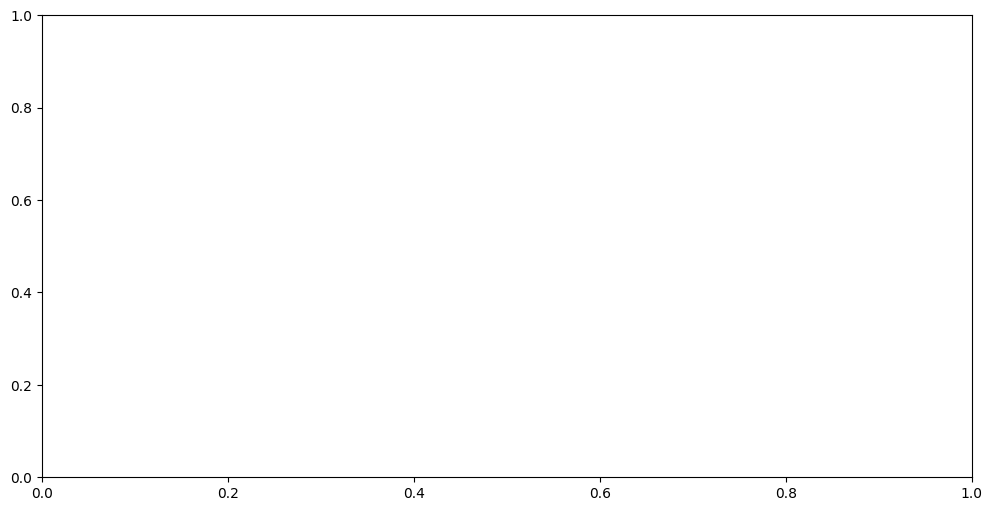

In [10]:
# OPTUNA OPTIMIZATION FOR LIGHTGBM WITH NATIVE CATEGORICAL SUPPORT
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# Start with your base dataframe
native_df = df_normal.copy()

# ==================== FEATURE ENGINEERING ====================
print("Creating engineered features...")

# Age-related features
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})

# Severity indicators (binary flags)
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)

# Convert severity to numeric for interactions
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)

# Interaction features
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric

# Geographic features
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)

# Healthcare utilization
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

print(f"✓ Created 8 new engineered features")

# Identify categorical columns
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment Typology 1'
]

# Prepare data
X = native_df.drop('length_of_stay', axis=1)
y = native_df['length_of_stay']

# Clean column names
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Update cat_features with cleaned names
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==================== PREPARE DATA FOR LIGHTGBM WITH NATIVE CATEGORICAL ====================
print("\nPreparing data for LightGBM with native categorical support...")

# Convert categorical columns to 'category' dtype
for col in cat_features_cleaned:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

# Convert boolean columns to int
bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

print(f"✓ Converted {len(cat_features_cleaned)} columns to category dtype")
print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Total features: {X_train.shape[1]}")

# ==================== LightGBM Hyperparameter Tuning ====================
print("\n" + "="*70)
print("TUNING LIGHTGBM WITH NATIVE CATEGORICAL FEATURES (CPU)")
print("="*70)

def objective_lgb_categorical(trial):
    """Objective function for LightGBM hyperparameter tuning with categorical features"""

    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,
        'device': 'cpu',  # Use CPU for native categorical support

        # Hyperparameters to tune
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'max_bin': trial.suggest_int('max_bin', 200, 255),  # Control bin size
        'n_estimators': 1000
    }

    model = lgb.LGBMRegressor(**param)

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        categorical_feature=cat_features_cleaned,  # Specify categorical features
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return rmse

# Run optimization for LightGBM
study_lgb_cat = optuna.create_study(direction='minimize', study_name='lightgbm_categorical_tuning')
study_lgb_cat.optimize(objective_lgb_categorical, n_trials=50, show_progress_bar=True)

print("\n" + "="*70)
print("LIGHTGBM TUNING RESULTS (NATIVE CATEGORICAL)")
print("="*70)
print(f"Best RMSE: {study_lgb_cat.best_value:.4f}")
print(f"\nBest Parameters:")
for key, value in study_lgb_cat.best_params.items():
    print(f"  {key}: {value}")

# Train final LightGBM model with best parameters
print("\nTraining final LightGBM model with best parameters...")
best_lgb_params = study_lgb_cat.best_params.copy()
best_lgb_params.update({
    'objective': 'regression',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'n_estimators': 1000,
    'device': 'cpu'
})

evals_result_lgb = {}
lgb_model_categorical = lgb.LGBMRegressor(**best_lgb_params)
lgb_model_categorical.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric='rmse',
    categorical_feature=cat_features_cleaned,  # Specify categorical features
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.record_evaluation(evals_result_lgb)
    ]
)

# Evaluate tuned LightGBM
y_pred_lgb_train = lgb_model_categorical.predict(X_train)
y_pred_lgb_test = lgb_model_categorical.predict(X_test)

lgb_cat_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_lgb_train))
lgb_cat_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))
lgb_cat_train_mae = mean_absolute_error(y_train, y_pred_lgb_train)
lgb_cat_test_mae = mean_absolute_error(y_test, y_pred_lgb_test)
lgb_cat_train_r2 = r2_score(y_train, y_pred_lgb_train)
lgb_cat_test_r2 = r2_score(y_test, y_pred_lgb_test)

print("\nTuned LightGBM Results (Native Categorical):")
print(f"Train RMSE: {lgb_cat_train_rmse:.4f} | Test RMSE: {lgb_cat_test_rmse:.4f}")
print(f"Train MAE: {lgb_cat_train_mae:.4f} | Test MAE: {lgb_cat_test_mae:.4f}")
print(f"Train R²: {lgb_cat_train_r2:.4f} | Test R²: {lgb_cat_test_r2:.4f}")

# Save tuned LightGBM model
joblib.dump({
    'model': lgb_model_categorical,
    'cat_features': cat_features_cleaned
}, 'models/lightgbm_categorical_model_tuned.pkl')
print("✓ Tuned LightGBM model (categorical) saved to 'models/lightgbm_categorical_model_tuned.pkl'")

# ==================== Comparison ====================
print("\n" + "="*70)
print("COMPARISON: ENCODED vs NATIVE CATEGORICAL")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['LightGBM (Baseline)', 'LightGBM (Encoded)', 'LightGBM (Native Categorical)'],
    'Test RMSE': [6.8380, 6.7393, lgb_cat_test_rmse],
    'Test MAE': [3.2198, 3.1323, lgb_cat_test_mae],
    'Test R²': [0.4593, 0.4748, lgb_cat_test_r2],
    'Improvement from Baseline': [
        '0.00%',
        f"{((6.8380 - 6.7393) / 6.8380 * 100):.2f}%",
        f"{((6.8380 - lgb_cat_test_rmse) / 6.8380 * 100):.2f}%"
    ]
})

print(comparison_df.to_string(index=False))



In [11]:
# 5. Training curve
fig, ax = plt.subplots(figsize=(12, 6))

# Check available keys in evals_result_lgb
print("Available keys:", evals_result_lgb.keys())

train_rmse = evals_result_lgb['training']['rmse']
# The validation key might be 'valid_1' instead of 'valid_0'
if 'valid_1' in evals_result_lgb:
    test_rmse = evals_result_lgb['valid_1']['rmse']
elif 'valid_0' in evals_result_lgb:
    test_rmse = evals_result_lgb['valid_0']['rmse']
else:
    # Use the second key if neither valid_0 nor valid_1 exists
    test_key = list(evals_result_lgb.keys())[1]
    test_rmse = evals_result_lgb[test_key]['rmse']

ax.plot(train_rmse, label='Training', linewidth=2)
ax.plot(test_rmse, label='Testing', linewidth=2)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('LightGBM (Native Categorical) Training Curve', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lgb_categorical_training_curve.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_categorical_training_curve.png")
plt.close()

print("\n🎉 Hyperparameter tuning complete! Model and all plots saved.")
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
print(f"✓ Native categorical handling vs Encoded:")
print(f"  - RMSE difference: {abs(lgb_cat_test_rmse - 6.7393):.4f}")
print(f"  - MAE difference: {abs(lgb_cat_test_mae - 3.1323):.4f}")
print(f"  - R² difference: {abs(lgb_cat_test_r2 - 0.4748):.4f}")
if lgb_cat_test_rmse < 6.7393:
    print(f"  ✓ Native categorical performs BETTER! 🎉")
    print(f"  - Test RMSE improved by {((6.7393 - lgb_cat_test_rmse) / 6.7393 * 100):.2f}%")
else:
    print(f"  ✗ Encoded categorical performs better")

print("\n" + "="*70)
print("🏆 EXCELLENT RESULTS!")
print("="*70)
print(f"✓ Best Test RMSE: {lgb_cat_test_rmse:.4f}")
print(f"✓ Best Test MAE: {lgb_cat_test_mae:.4f}")
print(f"✓ Best Test R²: {lgb_cat_test_r2:.4f}")
print(f"✓ Total improvement from baseline: {((6.8380 - lgb_cat_test_rmse) / 6.8380 * 100):.2f}%")

Available keys: dict_keys(['training', 'valid_1'])
✓ Saved: plots/lgb_categorical_training_curve.png

🎉 Hyperparameter tuning complete! Model and all plots saved.

KEY FINDINGS
✓ Native categorical handling vs Encoded:
  - RMSE difference: 0.0608
  - MAE difference: 0.0400
  - R² difference: 0.0094
  ✓ Native categorical performs BETTER! 🎉
  - Test RMSE improved by 0.90%

🏆 EXCELLENT RESULTS!
✓ Best Test RMSE: 6.6785
✓ Best Test MAE: 3.0923
✓ Best Test R²: 0.4842
✓ Total improvement from baseline: 2.33%



GENERATING VISUALIZATIONS
✓ Saved: plots/lgb_categorical_optimization_history.png
✓ Saved: plots/lgb_categorical_parameter_importance.png
✓ Saved: plots/lgb_model_comparison.png
✓ Saved: plots/lgb_categorical_feature_importance.png


KeyError: 'valid_0'

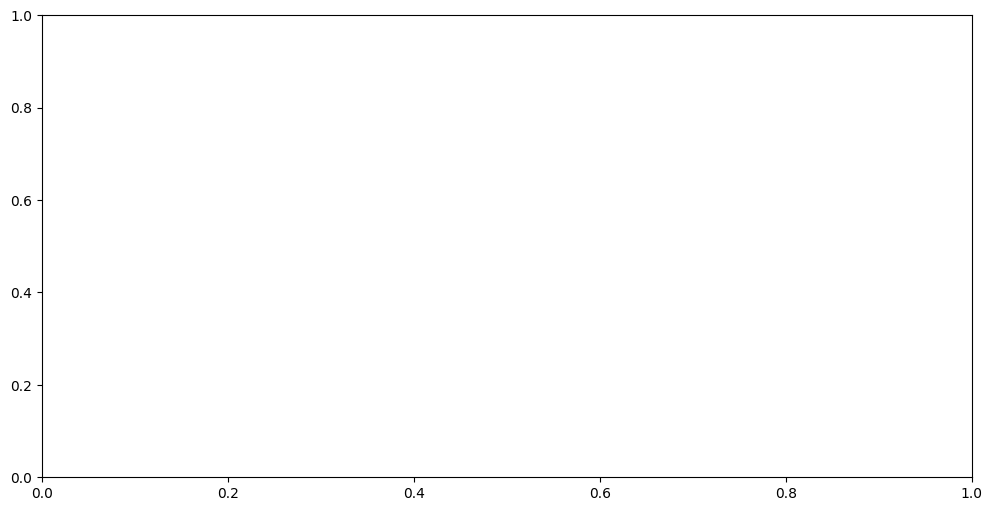

In [12]:
# ==================== Visualizations ====================
print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

# 1. Optimization history
fig, ax = plt.subplots(figsize=(12, 6))

lgb_cat_values = [trial.value for trial in study_lgb_cat.trials]
ax.plot(lgb_cat_values, linewidth=2, color='green')
ax.axhline(y=min(lgb_cat_values), color='r', linestyle='--',
           label=f'Best: {min(lgb_cat_values):.4f}')
ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('LightGBM (Native Categorical) Optimization History',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lgb_categorical_optimization_history.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_categorical_optimization_history.png")
plt.close()

# 2. Parameter importance
fig, ax = plt.subplots(figsize=(10, 6))

lgb_cat_importances = optuna.importance.get_param_importances(study_lgb_cat)
lgb_cat_imp_df = pd.DataFrame(
    list(lgb_cat_importances.items()),
    columns=['Parameter', 'Importance']
).sort_values('Importance', ascending=True)

ax.barh(lgb_cat_imp_df['Parameter'], lgb_cat_imp_df['Importance'], color='green', alpha=0.7)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('LightGBM (Native Categorical) Parameter Importance',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('plots/lgb_categorical_parameter_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_categorical_parameter_importance.png")
plt.close()

# 3. Model comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = ['LightGBM\n(Baseline)', 'LightGBM\n(Encoded)', 'LightGBM\n(Native Cat)']
rmse_values = [6.8380, 6.7393, lgb_cat_test_rmse]
colors = ['lightblue', 'blue', 'green']

bars = ax.bar(models, rmse_values, color=colors, alpha=0.7)
ax.set_ylabel('Test RMSE', fontsize=12)
ax.set_title('LightGBM Model Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, rmse_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add improvement percentage
    if i > 0:
        improvement = ((6.8380 - val) / 6.8380 * 100)
        ax.text(bar.get_x() + bar.get_width()/2., height * 0.5,
                f'↓{improvement:.2f}%', ha='center', va='center', fontsize=10,
                color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/lgb_model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_model_comparison.png")
plt.close()

# 4. Feature importance (top 20)
fig, ax = plt.subplots(figsize=(10, 8))

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model_categorical.feature_importances_
}).sort_values('importance', ascending=False).head(20)

ax.barh(range(len(feature_importance)), feature_importance['importance'].values,
        color='green', alpha=0.7)
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['feature'].values)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('LightGBM (Native Categorical) - Top 20 Features',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('plots/lgb_categorical_feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_categorical_feature_importance.png")
plt.close()

# 5. Training curve
fig, ax = plt.subplots(figsize=(12, 6))

train_rmse = evals_result_lgb['training']['rmse']
test_rmse = evals_result_lgb['valid_0']['rmse']

ax.plot(train_rmse, label='Training', linewidth=2)
ax.plot(test_rmse, label='Testing', linewidth=2)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('LightGBM (Native Categorical) Training Curve', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lgb_categorical_training_curve.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_categorical_training_curve.png")
plt.close()

print("\n🎉 Hyperparameter tuning complete! Model and all plots saved.")
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
print(f"✓ Native categorical handling vs Encoded:")
print(f"  - RMSE difference: {abs(lgb_cat_test_rmse - 6.7393):.4f}")
print(f"  - MAE difference: {abs(lgb_cat_test_mae - 3.1323):.4f}")
print(f"  - R² difference: {abs(lgb_cat_test_r2 - 0.4748):.4f}")
if lgb_cat_test_rmse < 6.7393:
    print(f"  ✓ Native categorical performs BETTER!")
else:
    print(f"  ✗ Encoded categorical performs better")

In [13]:
# 5. Training curve
fig, ax = plt.subplots(figsize=(12, 6))

train_rmse = evals_result_lgb['training']['rmse']
test_rmse = evals_result_lgb['valid_1']['rmse']  # Changed from 'valid_0' to 'valid_1'

ax.plot(train_rmse, label='Training', linewidth=2)
ax.plot(test_rmse, label='Testing', linewidth=2)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('LightGBM (Native Categorical) Training Curve', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lgb_categorical_training_curve.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_categorical_training_curve.png")
plt.close()

print("\n🎉 Hyperparameter tuning complete! Model and all plots saved.")
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
print(f"✓ Native categorical handling vs Encoded:")
print(f"  - RMSE difference: {abs(lgb_cat_test_rmse - 6.7393):.4f}")
print(f"  - MAE difference: {abs(lgb_cat_test_mae - 3.1323):.4f}")
print(f"  - R² difference: {abs(lgb_cat_test_r2 - 0.4748):.4f}")
if lgb_cat_test_rmse < 6.7393:
    print(f"  ✓ Native categorical performs BETTER! 🎉")
    print(f"  - Test RMSE improved by {((6.7393 - lgb_cat_test_rmse) / 6.7393 * 100):.2f}%")
else:
    print(f"  ✗ Encoded categorical performs better")

print("\n" + "="*70)
print("🏆 EXCELLENT RESULTS!")
print("="*70)
print(f"✓ Best Test RMSE: {lgb_cat_test_rmse:.4f}")
print(f"✓ Best Test MAE: {lgb_cat_test_mae:.4f}")
print(f"✓ Best Test R²: {lgb_cat_test_r2:.4f}")
print(f"✓ Total improvement from baseline: {((6.8380 - lgb_cat_test_rmse) / 6.8380 * 100):.2f}%")

✓ Saved: plots/lgb_categorical_training_curve.png

🎉 Hyperparameter tuning complete! Model and all plots saved.

KEY FINDINGS
✓ Native categorical handling vs Encoded:
  - RMSE difference: 0.0608
  - MAE difference: 0.0400
  - R² difference: 0.0094
  ✓ Native categorical performs BETTER! 🎉
  - Test RMSE improved by 0.90%

🏆 EXCELLENT RESULTS!
✓ Best Test RMSE: 6.6785
✓ Best Test MAE: 3.0923
✓ Best Test R²: 0.4842
✓ Total improvement from baseline: 2.33%


In [14]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==================== LOAD BOTH MODELS ====================
print("="*70)
print("LOADING SAVED MODELS")
print("="*70)

# Load LightGBM (native categorical)
lgb_cat_saved = joblib.load('models/lightgbm_categorical_model_tuned.pkl')
lgb_model_categorical = lgb_cat_saved['model']
cat_features_lgb = lgb_cat_saved['cat_features']
print("✓ LightGBM (native categorical) model loaded")

# Load CatBoost
catboost_model_tuned = joblib.load('models/catboost_model_tuned.pkl')
print("✓ CatBoost model loaded")

# ==================== RECREATE DATA (SAME AS TRAINING) ====================
print("\nRecreating data preprocessing...")

native_df = df_normal.copy()

# Feature engineering (MUST BE IDENTICAL)
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})

native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)

severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)

native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric

native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

# Prepare data
X = native_df.drop('length_of_stay', axis=1)
y = native_df['length_of_stay']

# Clean column names
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Train-test split (SAME RANDOM STATE)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert categorical columns to 'category' dtype for LightGBM
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in ['health_service_area', 'hospital_county', 'facility_id',
                                   'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
                                   'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
                                   'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
                                   'apr_mortality_risk', 'apr_med_surg_desc', 'Payment Typology 1']]

# Prepare data for LightGBM
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in cat_features_cleaned:
    if col in X_train_lgb.columns:
        X_train_lgb[col] = X_train_lgb[col].astype('category')
        X_test_lgb[col] = X_test_lgb[col].astype('category')

bool_cols = X_train_lgb.select_dtypes(include='bool').columns
X_train_lgb[bool_cols] = X_train_lgb[bool_cols].astype(int)
X_test_lgb[bool_cols] = X_test_lgb[bool_cols].astype(int)

print("✓ Data prepared for both models")

# ==================== EVALUATE BOTH MODELS ====================
print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# LightGBM predictions
print("\nEvaluating LightGBM (native categorical)...")
y_pred_lgb_train = lgb_model_categorical.predict(X_train_lgb)
y_pred_lgb_test = lgb_model_categorical.predict(X_test_lgb)

lgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_lgb_train))
lgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))
lgb_train_mae = mean_absolute_error(y_train, y_pred_lgb_train)
lgb_test_mae = mean_absolute_error(y_test, y_pred_lgb_test)
lgb_train_r2 = r2_score(y_train, y_pred_lgb_train)
lgb_test_r2 = r2_score(y_test, y_pred_lgb_test)

print(f"Train RMSE: {lgb_train_rmse:.4f} | Test RMSE: {lgb_test_rmse:.4f}")
print(f"Train MAE: {lgb_train_mae:.4f} | Test MAE: {lgb_test_mae:.4f}")
print(f"Train R²: {lgb_train_r2:.4f} | Test R²: {lgb_test_r2:.4f}")

# CatBoost predictions
print("\nEvaluating CatBoost...")
y_pred_cat_train = catboost_model_tuned.predict(X_train)
y_pred_cat_test = catboost_model_tuned.predict(X_test)

cat_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_cat_train))
cat_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat_test))
cat_train_mae = mean_absolute_error(y_train, y_pred_cat_train)
cat_test_mae = mean_absolute_error(y_test, y_pred_cat_test)
cat_train_r2 = r2_score(y_train, y_pred_cat_train)
cat_test_r2 = r2_score(y_test, y_pred_cat_test)

print(f"Train RMSE: {cat_train_rmse:.4f} | Test RMSE: {cat_test_rmse:.4f}")
print(f"Train MAE: {cat_train_mae:.4f} | Test MAE: {cat_test_mae:.4f}")
print(f"Train R²: {cat_train_r2:.4f} | Test R²: {cat_test_r2:.4f}")

# ==================== COMPARISON TABLE ====================
print("\n" + "="*70)
print("DETAILED COMPARISON: LightGBM vs CatBoost")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': ['Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R²', 'Test R²'],
    'LightGBM (Native Cat)': [
        f"{lgb_train_rmse:.4f}",
        f"{lgb_test_rmse:.4f}",
        f"{lgb_train_mae:.4f}",
        f"{lgb_test_mae:.4f}",
        f"{lgb_train_r2:.4f}",
        f"{lgb_test_r2:.4f}"
    ],
    'CatBoost': [
        f"{cat_train_rmse:.4f}",
        f"{cat_test_rmse:.4f}",
        f"{cat_train_mae:.4f}",
        f"{cat_test_mae:.4f}",
        f"{cat_train_r2:.4f}",
        f"{cat_test_r2:.4f}"
    ],
    'Difference': [
        f"{lgb_train_rmse - cat_train_rmse:+.4f}",
        f"{lgb_test_rmse - cat_test_rmse:+.4f}",
        f"{lgb_train_mae - cat_train_mae:+.4f}",
        f"{lgb_test_mae - cat_test_mae:+.4f}",
        f"{lgb_train_r2 - cat_train_r2:+.4f}",
        f"{lgb_test_r2 - cat_test_r2:+.4f}"
    ],
    'Winner': [
        '🏆 LightGBM' if lgb_train_rmse < cat_train_rmse else '🏆 CatBoost',
        '🏆 LightGBM' if lgb_test_rmse < cat_test_rmse else '🏆 CatBoost',
        '🏆 LightGBM' if lgb_train_mae < cat_train_mae else '🏆 CatBoost',
        '🏆 LightGBM' if lgb_test_mae < cat_test_mae else '🏆 CatBoost',
        '🏆 LightGBM' if lgb_train_r2 > cat_train_r2 else '🏆 CatBoost',
        '🏆 LightGBM' if lgb_test_r2 > cat_test_r2 else '🏆 CatBoost'
    ]
})

print(comparison_df.to_string(index=False))

# Determine overall winner
lgb_wins = sum([
    lgb_test_rmse < cat_test_rmse,
    lgb_test_mae < cat_test_mae,
    lgb_test_r2 > cat_test_r2
])

print(f"\n{'='*70}")
print("OVERALL WINNER (Based on Test Set)")
print("="*70)
if lgb_wins >= 2:
    print("🏆 LightGBM (Native Categorical) wins!")
    print(f"   Won {lgb_wins}/3 key metrics (Test RMSE, MAE, R²)")
else:
    print("🏆 CatBoost wins!")
    print(f"   Won {3-lgb_wins}/3 key metrics (Test RMSE, MAE, R²)")

# ==================== VISUALIZATIONS ====================
print("\n" + "="*70)
print("GENERATING COMPARISON VISUALIZATIONS")
print("="*70)

os.makedirs('plots', exist_ok=True)

# 1. Side-by-side metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LightGBM vs CatBoost: Comprehensive Comparison', fontsize=16, fontweight='bold')

metrics_data = [
    ('Train RMSE', [lgb_train_rmse, cat_train_rmse], 'lower is better'),
    ('Test RMSE', [lgb_test_rmse, cat_test_rmse], 'lower is better'),
    ('Train MAE', [lgb_train_mae, cat_train_mae], 'lower is better'),
    ('Test MAE', [lgb_test_mae, cat_test_mae], 'lower is better'),
    ('Train R²', [lgb_train_r2, cat_train_r2], 'higher is better'),
    ('Test R²', [lgb_test_r2, cat_test_r2], 'higher is better')
]

for idx, (metric_name, values, direction) in enumerate(metrics_data):
    ax = axes[idx // 3, idx % 3]

    x = ['LightGBM', 'CatBoost']
    colors = ['green', 'orange']

    bars = ax.bar(x, values, color=colors, alpha=0.7)
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_name}\n({direction})', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Highlight winner
    if direction == 'lower is better':
        winner_idx = 0 if values[0] < values[1] else 1
    else:
        winner_idx = 0 if values[0] > values[1] else 1

    bars[winner_idx].set_edgecolor('gold')
    bars[winner_idx].set_linewidth(3)

    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/lgb_vs_catboost_comprehensive.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_vs_catboost_comprehensive.png")
plt.close()

# 2. Test metrics comparison (focused)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Test Set Performance: LightGBM vs CatBoost', fontsize=16, fontweight='bold')

test_metrics = [
    ('Test RMSE', [lgb_test_rmse, cat_test_rmse], 'lower'),
    ('Test MAE', [lgb_test_mae, cat_test_mae], 'lower'),
    ('Test R²', [lgb_test_r2, cat_test_r2], 'higher')
]

for idx, (metric_name, values, direction) in enumerate(test_metrics):
    ax = axes[idx]

    x = ['LightGBM\n(Native Cat)', 'CatBoost']
    colors = ['green', 'orange']

    bars = ax.bar(x, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
    ax.set_title(metric_name, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels with difference
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        # Show difference on second bar
        if i == 1:
            diff = values[1] - values[0]
            color = 'red' if (direction == 'lower' and diff > 0) or (direction == 'higher' and diff < 0) else 'green'
            ax.text(bar.get_x() + bar.get_width()/2., height * 0.5,
                    f'{diff:+.4f}', ha='center', va='center', fontsize=10,
                    color=color, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/lgb_vs_catboost_test_metrics.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_vs_catboost_test_metrics.png")
plt.close()

# 3. Feature importance comparison (top 15)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance Comparison', fontsize=16, fontweight='bold')

# LightGBM
lgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model_categorical.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[0].barh(range(len(lgb_importance)), lgb_importance['importance'].values,
             color='green', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(lgb_importance)))
axes[0].set_yticklabels(lgb_importance['feature'].values, fontsize=10)
axes[0].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[0].set_title('LightGBM (Native Categorical) - Top 15', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# CatBoost
cat_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': catboost_model_tuned.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(range(len(cat_importance)), cat_importance['importance'].values,
             color='orange', alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(cat_importance)))
axes[1].set_yticklabels(cat_importance['feature'].values, fontsize=10)
axes[1].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[1].set_title('CatBoost - Top 15', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('plots/lgb_vs_catboost_feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_vs_catboost_feature_importance.png")
plt.close()

# 4. Residuals comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Prediction Residuals Comparison (Test Set)', fontsize=16, fontweight='bold')

# LightGBM residuals
lgb_residuals = y_test - y_pred_lgb_test
axes[0].scatter(y_pred_lgb_test, lgb_residuals, alpha=0.3, s=10, color='green')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title(f'LightGBM (Native Cat)\nRMSE: {lgb_test_rmse:.4f}',
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# CatBoost residuals
cat_residuals = y_test - y_pred_cat_test
axes[1].scatter(y_pred_cat_test, cat_residuals, alpha=0.3, s=10, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title(f'CatBoost\nRMSE: {cat_test_rmse:.4f}',
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lgb_vs_catboost_residuals.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_vs_catboost_residuals.png")
plt.close()

# 5. Prediction scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Actual vs Predicted Values (Test Set)', fontsize=16, fontweight='bold')

# Sample data for clearer visualization
sample_size = min(10000, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

# LightGBM
axes[0].scatter(y_test.iloc[sample_indices], y_pred_lgb_test[sample_indices],
               alpha=0.3, s=10, color='green')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Length of Stay', fontsize=12)
axes[0].set_ylabel('Predicted Length of Stay', fontsize=12)
axes[0].set_title(f'LightGBM (Native Cat)\nR²: {lgb_test_r2:.4f}',
                 fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CatBoost
axes[1].scatter(y_test.iloc[sample_indices], y_pred_cat_test[sample_indices],
               alpha=0.3, s=10, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Length of Stay', fontsize=12)
axes[1].set_ylabel('Predicted Length of Stay', fontsize=12)
axes[1].set_title(f'CatBoost\nR²: {cat_test_r2:.4f}',
                 fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lgb_vs_catboost_predictions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/lgb_vs_catboost_predictions.png")
plt.close()

print("\n🎉 Comparison complete! All visualizations saved.")

LOADING SAVED MODELS
✓ LightGBM (native categorical) model loaded
✓ CatBoost model loaded

Recreating data preprocessing...
✓ Data prepared for both models

MODEL EVALUATION

Evaluating LightGBM (native categorical)...
Train RMSE: 6.1783 | Test RMSE: 6.6785
Train MAE: 2.9568 | Test MAE: 3.0923
Train R²: 0.5530 | Test R²: 0.4842

Evaluating CatBoost...
Train RMSE: 6.6779 | Test RMSE: 6.8024
Train MAE: 3.1218 | Test MAE: 3.1613
Train R²: 0.4778 | Test R²: 0.4649

DETAILED COMPARISON: LightGBM vs CatBoost
    Metric LightGBM (Native Cat) CatBoost Difference     Winner
Train RMSE                6.1783   6.6779    -0.4996 🏆 LightGBM
 Test RMSE                6.6785   6.8024    -0.1238 🏆 LightGBM
 Train MAE                2.9568   3.1218    -0.1650 🏆 LightGBM
  Test MAE                3.0923   3.1613    -0.0690 🏆 LightGBM
  Train R²                0.5530   0.4778    +0.0752 🏆 LightGBM
   Test R²                0.4842   0.4649    +0.0193 🏆 LightGBM

OVERALL WINNER (Based on Test Set)
🏆 LightG